Product Name
HON 5400 Series Task Chairs for Big and Tall                     21870.5760
Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish    15610.9656
Bretford Rectangular Conference Table Tops                       12995.2915
Global Troy Executive Leather Low-Back Tilter                    12975.3820
SAFCO Arco Folding Chair                                         11572.7800
DMI Eclipse Executive Suite Bookcases                            11046.6090
Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back      10637.5280
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases          9917.6400
Bush Advantage Collection Racetrack Conference Table              9544.7250
GuestStacker Chair with Chrome Finish Legs                        9070.9440
Name: Sales, dtype: float64
                                           Product Name     Profit
2044  Chromcraft Bull-Nose Wood Oval Conference Tabl... -1862.3124
7     Riverside Palais Royal Lawyers Bookcase, Royal... -1665.052

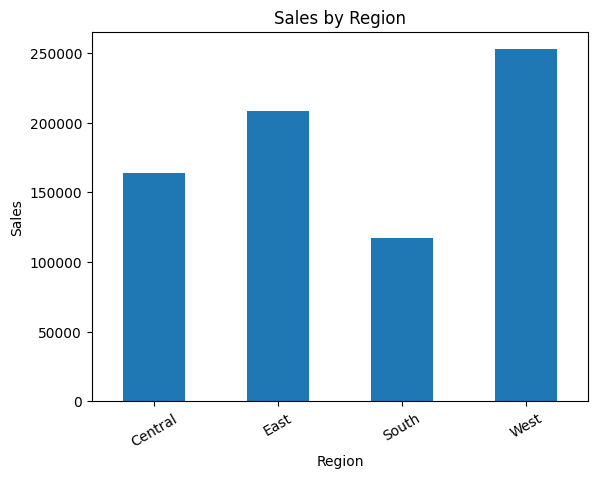

MAE: 306.315642305082


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# load data
df=pd.read_csv("../data/stores_sales_forecasting.csv",encoding='latin-1')
# print(df.head())

# convert dates
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

# add fiture 
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month
df['Day']=df['Order Date'].dt.date
df['Weekday']=df['Order Date'].dt.day_name()

# profit margin
df['Profit Margin']=df['Profit']/df['Sales']

# Business Insights (EDA)
# top products
top_products=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

# loos making products
loss=df[df['Profit']<0]
print(loss[['Product Name','Profit']].sort_values(by='Profit', ascending=True).head(10))

# sales regios
region_sales=df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='bar',title='Sales by Region',rot=30)
plt.ylabel('Sales')
plt.show()

# time serise data
ts=df.groupby('Order Date')['Sales'].sum()
ts=ts.asfreq('D')
ts = ts.fillna(0)

# moving avg
ts_ma = ts.rolling(window=7).mean()

# # arima model
# ...


# mechin learning model 
# Features
X=df[['Quantity','Discount','Month','Year']]
y=df['Sales']
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
model=RandomForestRegressor()
model.fit(X_train,y_train)
pred=model.predict(X_test)

# evalution
print("MAE:", mean_absolute_error(y_test, pred))

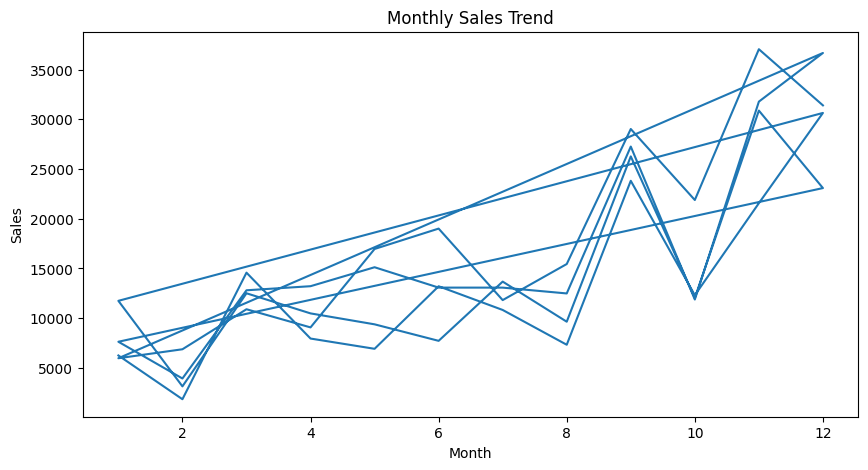

In [6]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


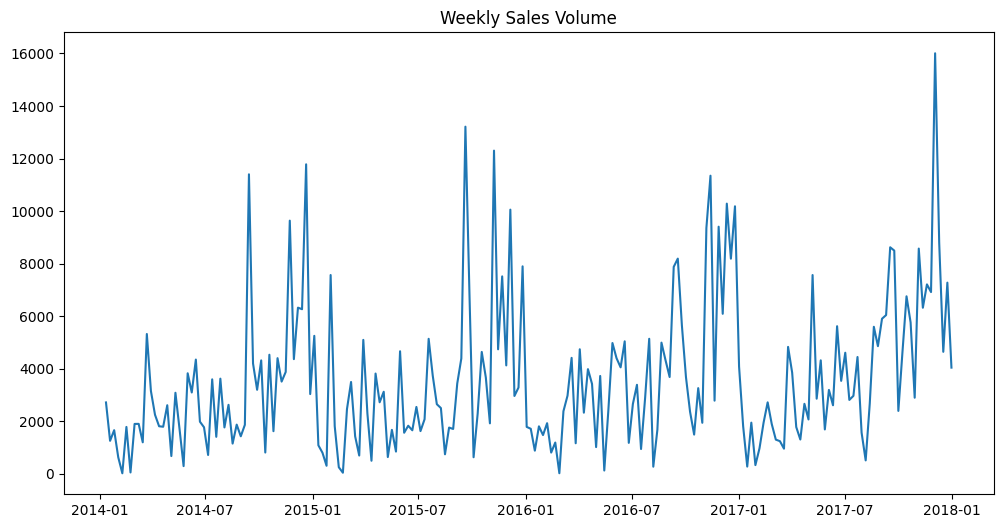

In [27]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df_subset=df[['Order Date','Sales']]
df_daily=df_subset.groupby('Order Date').sum()
df_weekly=df_daily['Sales'].resample('W').sum()
plt.figure(figsize=(12,6))
plt.plot(df_weekly)
plt.title('Weekly Sales Volume')
plt.show()

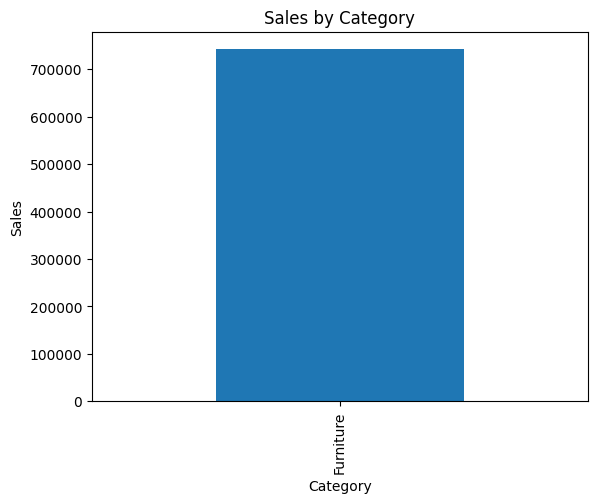

In [8]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', title="Sales by Category")
plt.ylabel("Sales")
plt.show()

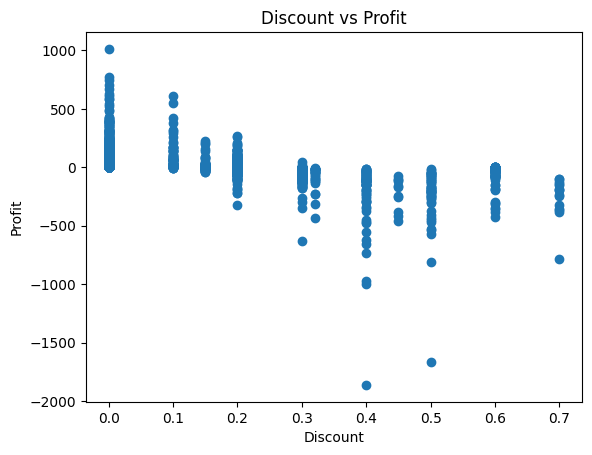

In [13]:
plt.scatter(df['Discount'], df['Profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

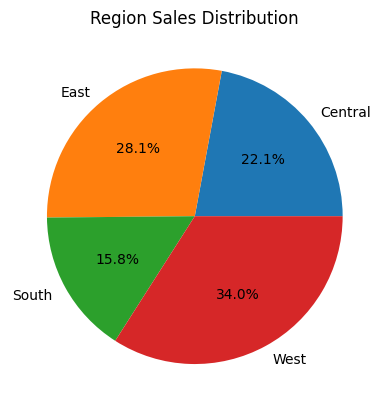

In [15]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%', title="Region Sales Distribution")
plt.ylabel("")
plt.show()

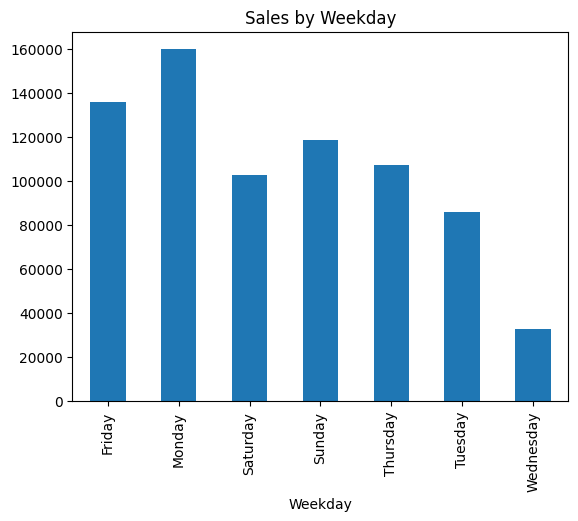

In [17]:
weekday_sales = df.groupby('Weekday')['Sales'].sum()

weekday_sales.plot(kind='bar', title="Sales by Weekday")
plt.show()

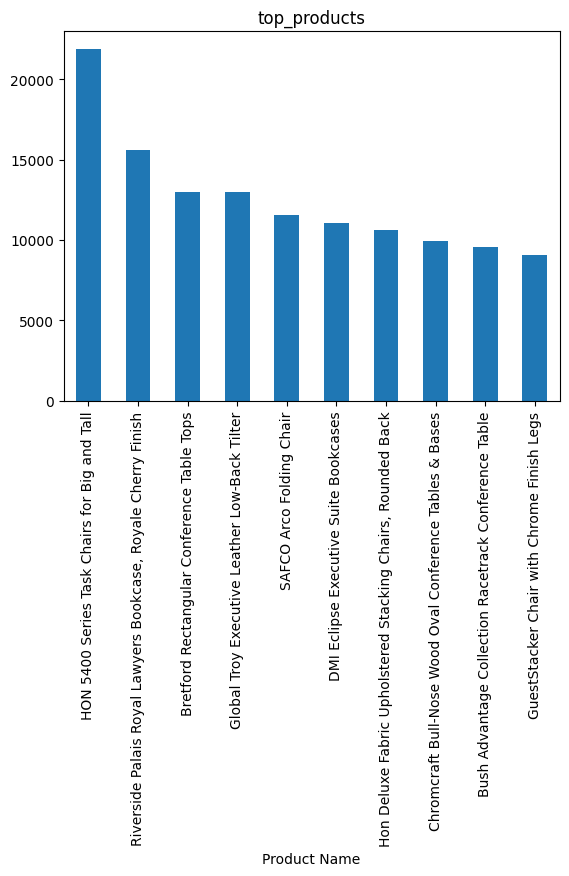

In [10]:
top_products.plot(kind='bar', title="top_products")
plt.show()

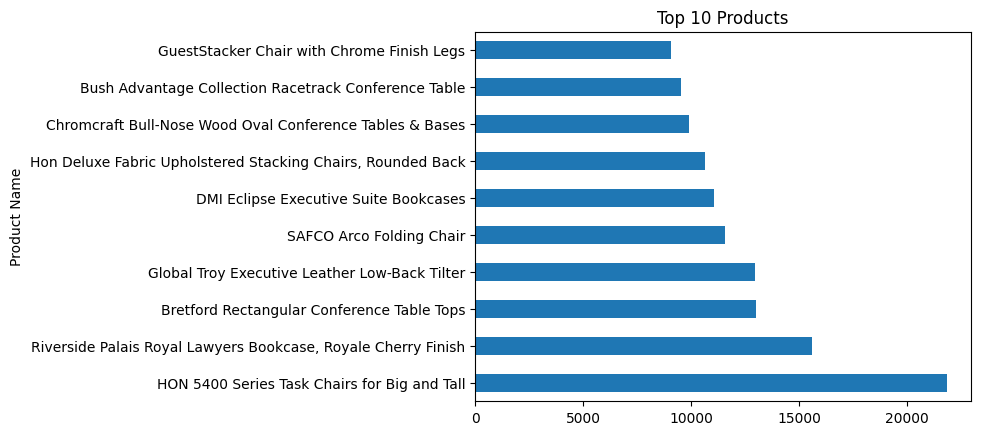

In [19]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

top_products.plot(kind='barh', title="Top 10 Products")
plt.show()

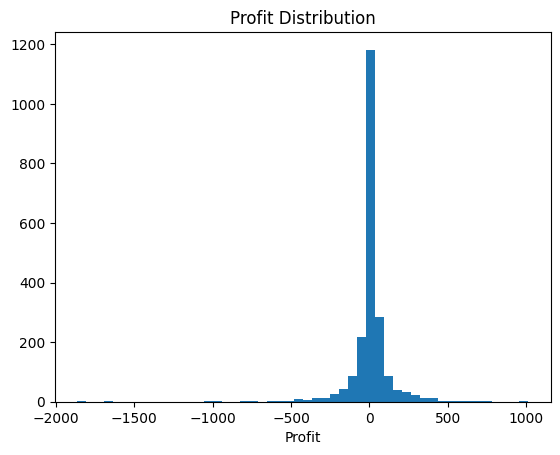

In [21]:
plt.hist(df['Profit'], bins=50)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.show()

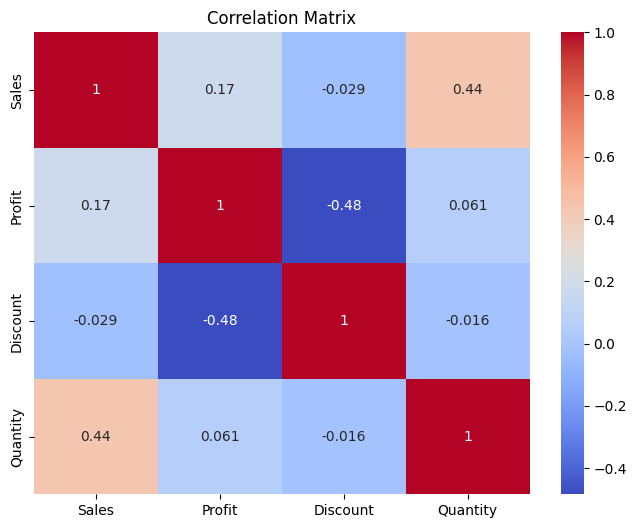

In [23]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

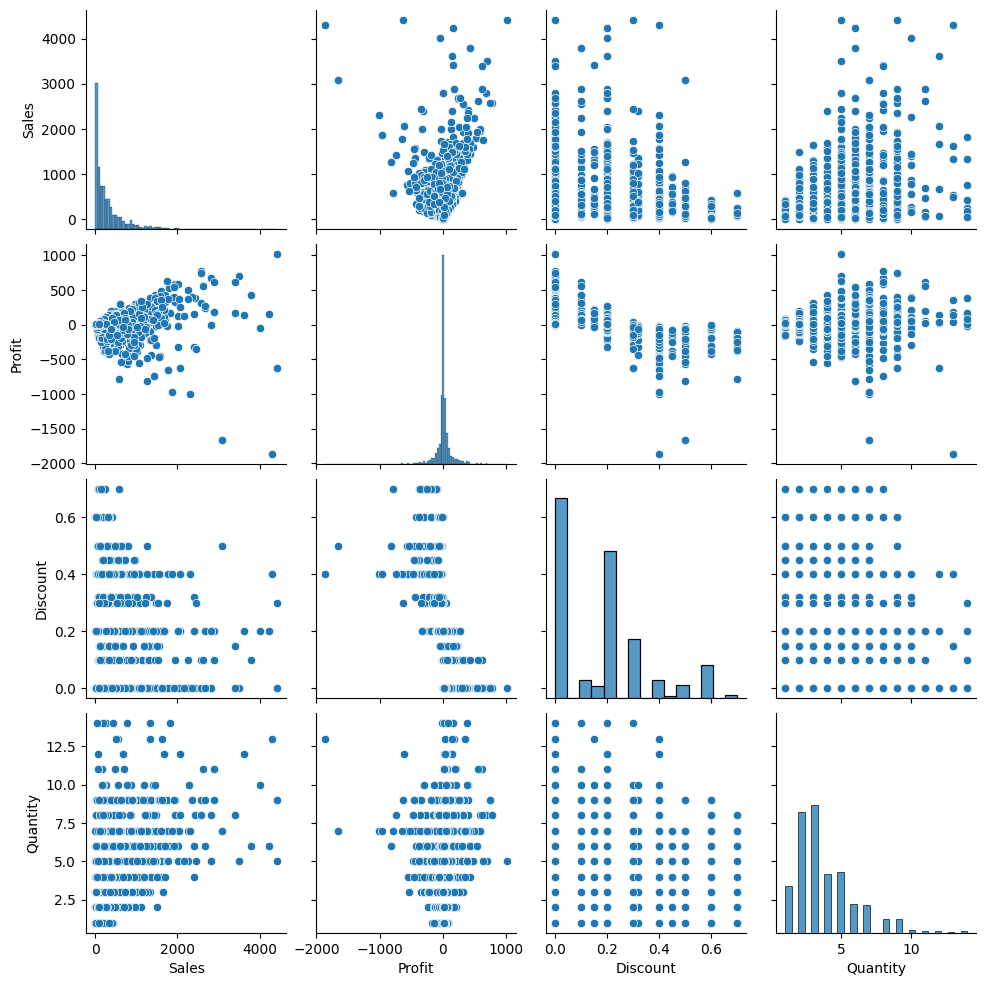

In [26]:
sns.pairplot(df[['Sales','Profit','Discount','Quantity']])
plt.show()